# Word Frequency and Correct-Position Analysis

This notebook analyzes the authoritative five-word sentence reconstruction dataset and the trained Transformer.

It answers two questions:

1. **How often does every word occur in the complete dataset?**
2. **For each word, how often does the trained model predict it in the correct target position?**

The second analysis is reported separately for **training**, **validation**, and **test** data. The protected test set is **not evaluated again**; its already-saved prediction file is read instead.

> Counting rule: word frequency is calculated from input sentences only. Input and target contain the same word multiset, so counting both would double every frequency.

In [1]:
from collections import Counter
from csv import DictWriter
from html import escape
import json
from pathlib import Path

from IPython.display import HTML, Markdown, display
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, PercentFormatter
import torch
from torch.utils.data import DataLoader

from config import best_weights_file_path, get_config
from dataset import SentenceReconstructionDataset, get_or_build_tokenizer, load_jsonl
from train import decoded_token_ids_to_words, get_model, greedy_decode

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "font.size": 10,
})

CONFIG = get_config()
PROJECT_ROOT = Path.cwd()
ANALYSIS_DIR = Path(CONFIG["experiment_root"]) / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "navy": "#0B132B",
    "teal": "#14B8A6",
    "violet": "#7C3AED",
    "blue": "#3B82F6",
    "orange": "#F59E0B",
    "red": "#EF4444",
    "gray": "#64748B",
}

print("Project:", PROJECT_ROOT)
print("Analysis outputs:", ANALYSIS_DIR)

ModuleNotFoundError: No module named 'matplotlib'

## Helper functions

The notebook uses only the project's pinned dependencies. Complete numeric tables are displayed as scrollable HTML and also exported as CSV files.

In [ ]:
def display_scrollable_table(rows, columns, title, max_height=430):
    """Display every row in a compact scrollable HTML table."""
    header = "".join(
        f"<th style='position:sticky;top:0;background:#0B132B;color:white;padding:7px;text-align:left'>{escape(label)}</th>"
        for _, label in columns
    )
    body_rows = []
    for index, row in enumerate(rows):
        background = "#F1F5F9" if index % 2 else "white"
        cells_html = "".join(
            f"<td style='padding:6px;border-bottom:1px solid #E2E8F0'>{escape(str(row[key]))}</td>"
            for key, _ in columns
        )
        body_rows.append(f"<tr style='background:{background}'>{cells_html}</tr>")

    display(HTML(f"""
    <h3 style='font-family:Segoe UI;color:#0B132B'>{escape(title)}</h3>
    <div style='max-height:{max_height}px;overflow:auto;border:1px solid #CBD5E1;border-radius:8px'>
      <table style='border-collapse:collapse;width:100%;font-family:Segoe UI;font-size:13px'>
        <thead><tr>{header}</tr></thead>
        <tbody>{''.join(body_rows)}</tbody>
      </table>
    </div>
    <p style='color:#64748B;font-family:Segoe UI'>Rows shown: {len(rows):,}</p>
    """))


def write_csv(path, rows, fieldnames):
    with Path(path).open("w", encoding="utf-8", newline="") as file:
        writer = DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def add_bar_labels(ax, decimals=0, suffix=""):
    for patch in ax.patches:
        value = patch.get_width() if patch.get_width() else patch.get_height()
        if value == 0:
            continue
        if patch.get_width() >= patch.get_height():
            ax.text(
                patch.get_x() + patch.get_width(),
                patch.get_y() + patch.get_height() / 2,
                f" {value:.{decimals}f}{suffix}",
                va="center",
                fontsize=8,
            )
        else:
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                patch.get_y() + patch.get_height(),
                f"{value:.{decimals}f}{suffix}",
                ha="center",
                va="bottom",
                fontsize=8,
            )


def save_figure(filename):
    path = ANALYSIS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print("Saved:", path)
    plt.show()

## 1. Load and verify the authoritative splits

In [ ]:
records_by_split = {
    "train": load_jsonl(CONFIG["train_file"]),
    "validation": load_jsonl(CONFIG["validation_file"]),
    "test": load_jsonl(CONFIG["test_file"]),
}

split_summary = []
for split_name, records in records_by_split.items():
    split_summary.append({
        "split": split_name.title(),
        "records": len(records),
        "input_word_occurrences": sum(len(row["input"].split()) for row in records),
        "unique_input_words": len({word for row in records for word in row["input"].split()}),
    })

display_scrollable_table(
    split_summary,
    [
        ("split", "Split"),
        ("records", "Records"),
        ("input_word_occurrences", "Input word occurrences"),
        ("unique_input_words", "Unique words"),
    ],
    "Dataset split summary",
    max_height=250,
)

assert [len(records_by_split[name]) for name in ("train", "validation", "test")] == [1014, 128, 127]
assert sum(len(records) for records in records_by_split.values()) == 1269
print("Dataset checks passed.")

Split,Records,Input word occurrences,Unique words
Train,1014,5070,1107
Validation,128,640,250
Test,127,635,248


Dataset checks passed.


## 2. Frequency of every word in the complete dataset

Each word occurrence is counted from the input sentence. Since every target is a permutation of its input, this counts the linguistic words exactly once per record.

In [ ]:
all_records = (
    records_by_split["train"]
    + records_by_split["validation"]
    + records_by_split["test"]
)

overall_word_frequency = Counter(
    word
    for record in all_records
    for word in record["input"].split()
)

word_frequency_rows = [
    {
        "rank": rank,
        "word": word,
        "frequency": count,
        "dataset_percentage": f"{count / (len(all_records) * 5) * 100:.3f}%",
    }
    for rank, (word, count) in enumerate(
        sorted(overall_word_frequency.items(), key=lambda item: (-item[1], item[0])),
        start=1,
    )
]

word_frequency_csv = ANALYSIS_DIR / "all_dataset_word_frequencies.csv"
write_csv(
    word_frequency_csv,
    word_frequency_rows,
    ["rank", "word", "frequency", "dataset_percentage"],
)

print(f"Total word occurrences: {sum(overall_word_frequency.values()):,}")
print(f"Unique ordinary words: {len(overall_word_frequency):,}")
print(f"Most frequent word: {word_frequency_rows[0]['word']!r} ({word_frequency_rows[0]['frequency']} appearances)")
print("Complete CSV:", word_frequency_csv)

display_scrollable_table(
    word_frequency_rows,
    [
        ("rank", "Rank"),
        ("word", "Word"),
        ("frequency", "Frequency"),
        ("dataset_percentage", "Percentage of all words"),
    ],
    "Complete word-frequency table",
)

Total word occurrences: 6,345
Unique ordinary words: 1,353
Most frequent word: 'he' (413 appearances)
Complete CSV: C:\Users\Shushant\Desktop\5 word transformer\experiments\new_authoritative_splits_1269\analysis\all_dataset_word_frequencies.csv


Rank,Word,Frequency,Percentage of all words
1,he,413,6.509%
2,i,197,3.105%
3,is,184,2.900%
4,you,138,2.175%
5,not,136,2.143%
6,she,100,1.576%
7,to,99,1.560%
8,can,74,1.166%
9,every,67,1.056%
10,after,65,1.024%


### Word-frequency charts

- The **bar chart** displays the exact counts of the 30 most frequent words.
- The **histogram** shows how many unique words occur once, twice, three times, and so on.

In [ ]:
top_n = 30
top_words = word_frequency_rows[:top_n][::-1]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(
    [row["word"] for row in top_words],
    [row["frequency"] for row in top_words],
    color=COLORS["teal"],
)
ax.set_title(f"Top {top_n} most frequent words across all 1,269 records", weight="bold")
ax.set_xlabel("Number of appearances")
ax.set_ylabel("Word")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
for bar, row in zip(bars, top_words):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f" {row['frequency']}", va="center", fontsize=8)
save_figure("top_30_word_frequencies.png")

Saved: C:\Users\Shushant\Desktop\5 word transformer\experiments\new_authoritative_splits_1269\analysis\top_30_word_frequencies.png


<Figure size 1440x1080 with 1 Axes>

Saved: C:\Users\Shushant\Desktop\5 word transformer\experiments\new_authoritative_splits_1269\analysis\word_frequency_histogram.png


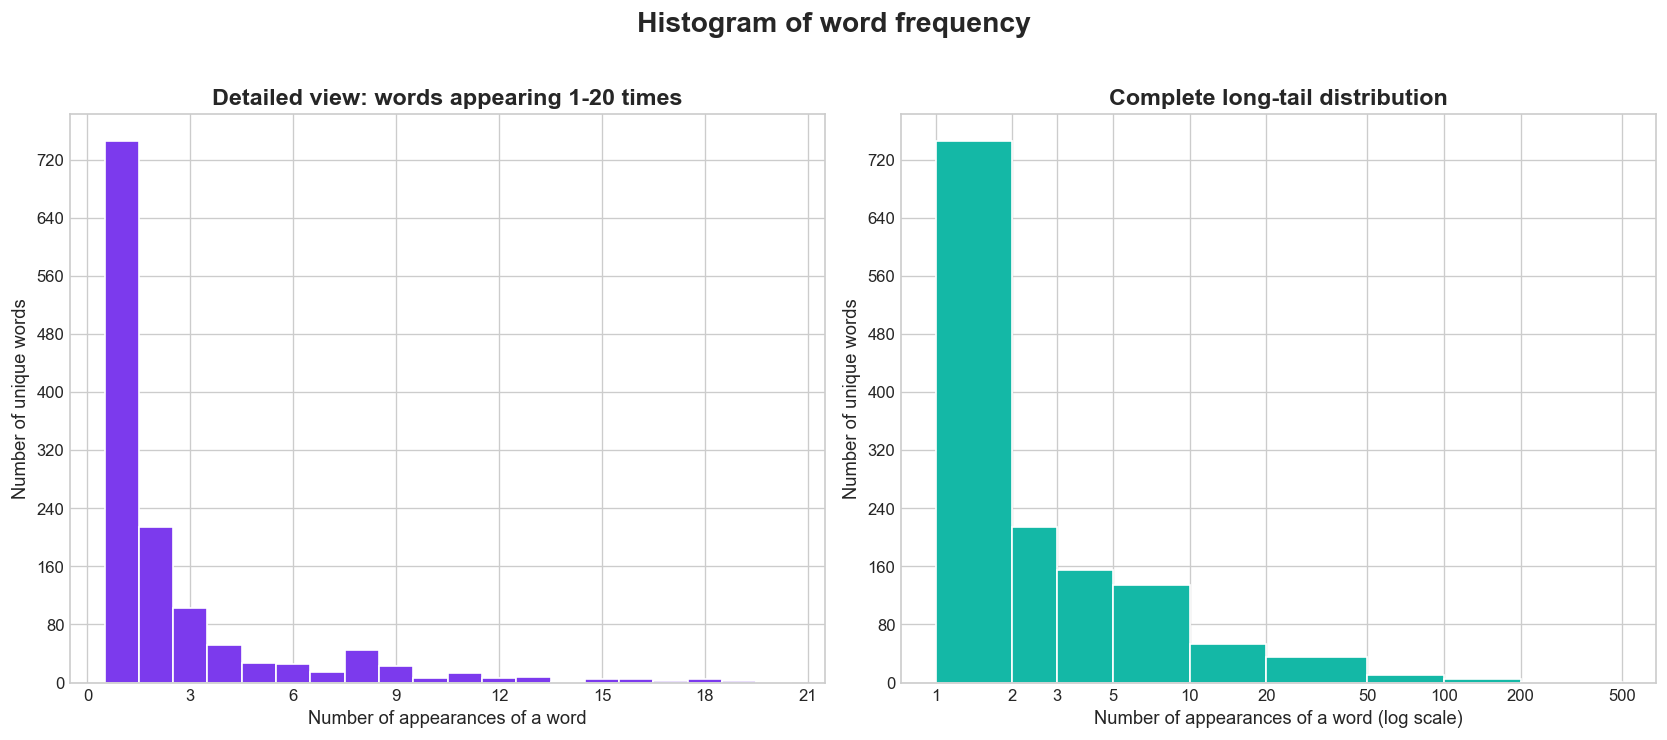

Appearances per word,Number of unique words
1,745
2,214
3,103
4,52
5,27
6,25
7,14
8,45
9,23
10,6


In [ ]:
frequency_values = list(overall_word_frequency.values())
maximum_frequency = max(frequency_values)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

common_frequencies = [value for value in frequency_values if value <= 20]
axes[0].hist(
    common_frequencies,
    bins=range(1, 22),
    align="left",
    color=COLORS["violet"],
    edgecolor="white",
)
axes[0].set_title("Detailed view: words appearing 1-20 times", weight="bold")
axes[0].set_xlabel("Number of appearances of a word")
axes[0].set_ylabel("Number of unique words")
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))

log_bins = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500]
axes[1].hist(
    frequency_values,
    bins=log_bins,
    color=COLORS["teal"],
    edgecolor="white",
)
axes[1].set_xscale("log")
axes[1].set_xticks(log_bins, [str(value) for value in log_bins])
axes[1].set_title("Complete long-tail distribution", weight="bold")
axes[1].set_xlabel("Number of appearances of a word (log scale)")
axes[1].set_ylabel("Number of unique words")
axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))

fig.suptitle("Histogram of word frequency", fontsize=17, weight="bold", y=1.02)
save_figure("word_frequency_histogram.png")

frequency_of_frequencies = Counter(frequency_values)
frequency_distribution_rows = [
    {
        "appearances": appearances,
        "number_of_unique_words": number_of_words,
    }
    for appearances, number_of_words in sorted(frequency_of_frequencies.items())
]
display_scrollable_table(
    frequency_distribution_rows,
    [
        ("appearances", "Appearances per word"),
        ("number_of_unique_words", "Number of unique words"),
    ],
    "Numbers behind the frequency histogram",
    max_height=300,
)

## 3. Generate or load predictions

- **Training and validation:** predictions are generated from the frozen `best_model.pt` checkpoint without gradients or parameter updates. They are cached in the experiment analysis folder.
- **Test:** the already-saved final test predictions are loaded. The test set is not evaluated again.

In [ ]:
DEVICE = torch.device("cpu")
TOKENIZER = get_or_build_tokenizer(CONFIG)
MODEL = get_model(CONFIG, TOKENIZER.get_vocab_size()).to(DEVICE)

checkpoint_path = Path(best_weights_file_path(CONFIG))
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
MODEL.load_state_dict(checkpoint["model_state_dict"])
MODEL.eval()

print("Checkpoint:", checkpoint_path)
print("Selected epoch:", checkpoint["epoch"])
print("Vocabulary size:", TOKENIZER.get_vocab_size())
print("Device:", DEVICE)

Checkpoint: C:\Users\Shushant\Desktop\5 word transformer\experiments\new_authoritative_splits_1269\weights\best_model.pt
Selected epoch: 3
Vocabulary size: 1357
Device: cpu


In [ ]:
def read_jsonl(path):
    rows = []
    with Path(path).open("r", encoding="utf-8") as file:
        for line in file:
            if line.strip():
                rows.append(json.loads(line))
    return rows


def write_jsonl(path, rows):
    with Path(path).open("w", encoding="utf-8") as file:
        for row in rows:
            file.write(json.dumps(row, ensure_ascii=False) + "\n")


def generate_predictions(records, split_name):
    cache_path = ANALYSIS_DIR / f"{split_name}_predictions.jsonl"
    if cache_path.exists():
        cached = read_jsonl(cache_path)
        if len(cached) == len(records):
            print(f"Loaded {len(cached):,} cached {split_name} predictions")
            return cached

    dataset = SentenceReconstructionDataset(records, TOKENIZER, CONFIG["seq_len"])
    loader = DataLoader(dataset, batch_size=1, shuffle=False)
    predictions = []

    with torch.no_grad():
        for index, batch in enumerate(loader, start=1):
            generated_ids = greedy_decode(
                MODEL,
                batch["encoder_input"].to(DEVICE),
                batch["encoder_mask"].to(DEVICE),
                TOKENIZER,
                CONFIG["seq_len"],
                DEVICE,
            )
            predicted_words, ended_with_eos = decoded_token_ids_to_words(
                generated_ids,
                TOKENIZER,
            )
            predictions.append({
                "input": batch["src_text"][0],
                "target": batch["tgt_text"][0],
                "prediction": " ".join(predicted_words),
                "ended_with_eos": ended_with_eos,
            })
            if index % 200 == 0 or index == len(loader):
                print(f"{split_name.title()}: {index:,}/{len(loader):,}")

    write_jsonl(cache_path, predictions)
    print("Saved:", cache_path)
    return predictions


train_predictions = generate_predictions(records_by_split["train"], "train")
validation_predictions = generate_predictions(records_by_split["validation"], "validation")

saved_test_path = Path(CONFIG["test_predictions_file"])
if not saved_test_path.exists():
    raise FileNotFoundError(
        "Saved final test predictions were not found. The notebook will not rerun the protected test evaluation."
    )
test_predictions = read_jsonl(saved_test_path)
print(f"Loaded {len(test_predictions):,} saved test predictions from {saved_test_path}")

predictions_by_split = {
    "train": train_predictions,
    "validation": validation_predictions,
    "test": test_predictions,
}

assert len(train_predictions) == 1014
assert len(validation_predictions) == 128
assert len(test_predictions) == 127

Loaded 1,014 cached train predictions
Loaded 128 cached validation predictions
Loaded 127 saved test predictions from C:\Users\Shushant\Desktop\5 word transformer\experiments\new_authoritative_splits_1269\results\test_predictions.jsonl


## 4. Correct-position distribution for each split

For a target word at position `i`, the prediction is correct only when:

```text
predicted_words[i] == target_words[i]
```

For every word:

```text
position accuracy = correct-position count / target appearances
```

Repeated words are counted separately at each target position.

In [ ]:
def calculate_position_statistics(prediction_records):
    appearances = Counter()
    correct = Counter()
    position_appearances = [0] * 5
    position_correct = [0] * 5

    for record in prediction_records:
        target_words = record["target"].split()
        predicted_words = record["prediction"].split()
        if len(target_words) != 5:
            raise ValueError(f"Expected five target words: {record}")

        for position, target_word in enumerate(target_words):
            appearances[target_word] += 1
            position_appearances[position] += 1
            is_correct = (
                position < len(predicted_words)
                and predicted_words[position] == target_word
            )
            if is_correct:
                correct[target_word] += 1
                position_correct[position] += 1

    rows = []
    for word, count in appearances.items():
        correct_count = correct[word]
        rows.append({
            "word": word,
            "target_appearances": count,
            "correct_positions": correct_count,
            "incorrect_positions": count - correct_count,
            "position_accuracy": correct_count / count,
            "position_accuracy_percent": f"{correct_count / count * 100:.2f}%",
        })

    rows.sort(key=lambda row: (-row["target_appearances"], row["word"]))
    per_position = [
        {
            "position": position + 1,
            "appearances": position_appearances[position],
            "correct": position_correct[position],
            "accuracy": position_correct[position] / position_appearances[position],
        }
        for position in range(5)
    ]
    return rows, per_position


position_rows_by_split = {}
per_position_by_split = {}
position_summary = []

for split_name, prediction_records in predictions_by_split.items():
    rows, per_position = calculate_position_statistics(prediction_records)
    position_rows_by_split[split_name] = rows
    per_position_by_split[split_name] = per_position

    total_positions = sum(row["target_appearances"] for row in rows)
    correct_positions = sum(row["correct_positions"] for row in rows)
    position_summary.append({
        "split": split_name.title(),
        "records": len(prediction_records),
        "target_positions": total_positions,
        "correct_positions": correct_positions,
        "word_position_accuracy": f"{correct_positions / total_positions * 100:.3f}%",
        "unique_target_words": len(rows),
    })

    csv_path = ANALYSIS_DIR / f"{split_name}_word_position_accuracy.csv"
    write_csv(
        csv_path,
        rows,
        [
            "word",
            "target_appearances",
            "correct_positions",
            "incorrect_positions",
            "position_accuracy",
            "position_accuracy_percent",
        ],
    )
    print("Saved:", csv_path)

display_scrollable_table(
    position_summary,
    [
        ("split", "Split"),
        ("records", "Records"),
        ("target_positions", "Target positions"),
        ("correct_positions", "Correct positions"),
        ("word_position_accuracy", "Word-position accuracy"),
        ("unique_target_words", "Unique target words"),
    ],
    "Correct-position summary",
    max_height=260,
)

Saved: C:\Users\Shushant\Desktop\5 word transformer\experiments\new_authoritative_splits_1269\analysis\train_word_position_accuracy.csv
Saved: C:\Users\Shushant\Desktop\5 word transformer\experiments\new_authoritative_splits_1269\analysis\validation_word_position_accuracy.csv
Saved: C:\Users\Shushant\Desktop\5 word transformer\experiments\new_authoritative_splits_1269\analysis\test_word_position_accuracy.csv


Split,Records,Target positions,Correct positions,Word-position accuracy,Unique target words
Train,1014,5070,1493,29.448%,1107
Validation,128,640,212,33.125%,250
Test,127,635,179,28.189%,248


### Train: complete per-word numeric table

In [ ]:
display_scrollable_table(
    position_rows_by_split["train"],
    [
        ("word", "Word"),
        ("target_appearances", "Target appearances"),
        ("correct_positions", "Correct positions"),
        ("incorrect_positions", "Incorrect positions"),
        ("position_accuracy_percent", "Position accuracy"),
    ],
    "Train word-level correct-position distribution",
)

Word,Target appearances,Correct positions,Incorrect positions,Position accuracy
he,367,354,13,96.46%
i,197,167,30,84.77%
is,167,57,110,34.13%
not,124,17,107,13.71%
you,121,21,100,17.36%
to,68,1,67,1.47%
every,67,0,67,0.00%
after,64,0,64,0.00%
before,61,1,60,1.64%
during,60,0,60,0.00%


### Validation: complete per-word numeric table

In [ ]:
display_scrollable_table(
    position_rows_by_split["validation"],
    [
        ("word", "Word"),
        ("target_appearances", "Target appearances"),
        ("correct_positions", "Correct positions"),
        ("incorrect_positions", "Incorrect positions"),
        ("position_accuracy_percent", "Position accuracy"),
    ],
    "Validation word-level correct-position distribution",
)

Word,Target appearances,Correct positions,Incorrect positions,Position accuracy
he,23,18,5,78.26%
she,19,11,8,57.89%
never,17,4,13,23.53%
often,17,1,16,5.88%
to,16,0,16,0.00%
why,14,1,13,7.14%
can,11,7,4,63.64%
daily,11,0,11,0.00%
does,10,10,0,100.00%
look,10,10,0,100.00%


### Test: complete per-word numeric table

In [ ]:
display_scrollable_table(
    position_rows_by_split["test"],
    [
        ("word", "Word"),
        ("target_appearances", "Target appearances"),
        ("correct_positions", "Correct positions"),
        ("incorrect_positions", "Incorrect positions"),
        ("position_accuracy_percent", "Position accuracy"),
    ],
    "Test word-level correct-position distribution",
)

Word,Target appearances,Correct positions,Incorrect positions,Position accuracy
he,23,14,9,60.87%
she,21,18,3,85.71%
often,20,1,19,5.00%
to,15,0,15,0.00%
never,13,4,9,30.77%
him,11,0,11,0.00%
is,11,11,0,100.00%
teaching,11,0,11,0.00%
daily,10,1,9,10.00%
why,10,0,10,0.00%


## 5. Correct-position count charts

For each split, the chart below shows the most frequently occurring target words and how many of those appearances were predicted in the correct position.

Saved: C:\Users\Shushant\Desktop\5 word transformer\experiments\new_authoritative_splits_1269\analysis\train_top_word_correct_position_counts.png


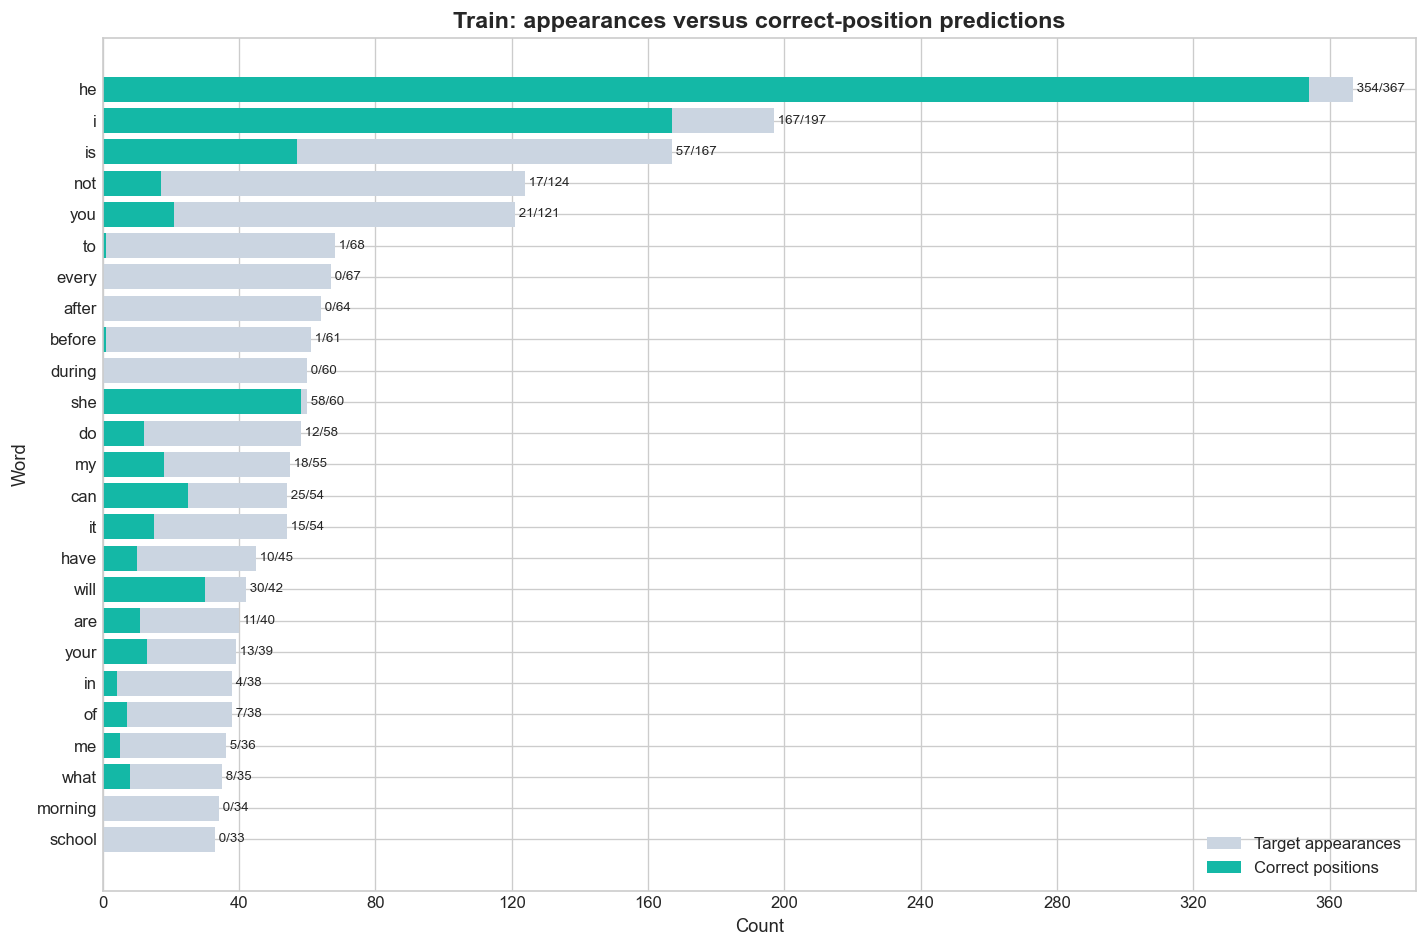

Saved: C:\Users\Shushant\Desktop\5 word transformer\experiments\new_authoritative_splits_1269\analysis\validation_top_word_correct_position_counts.png


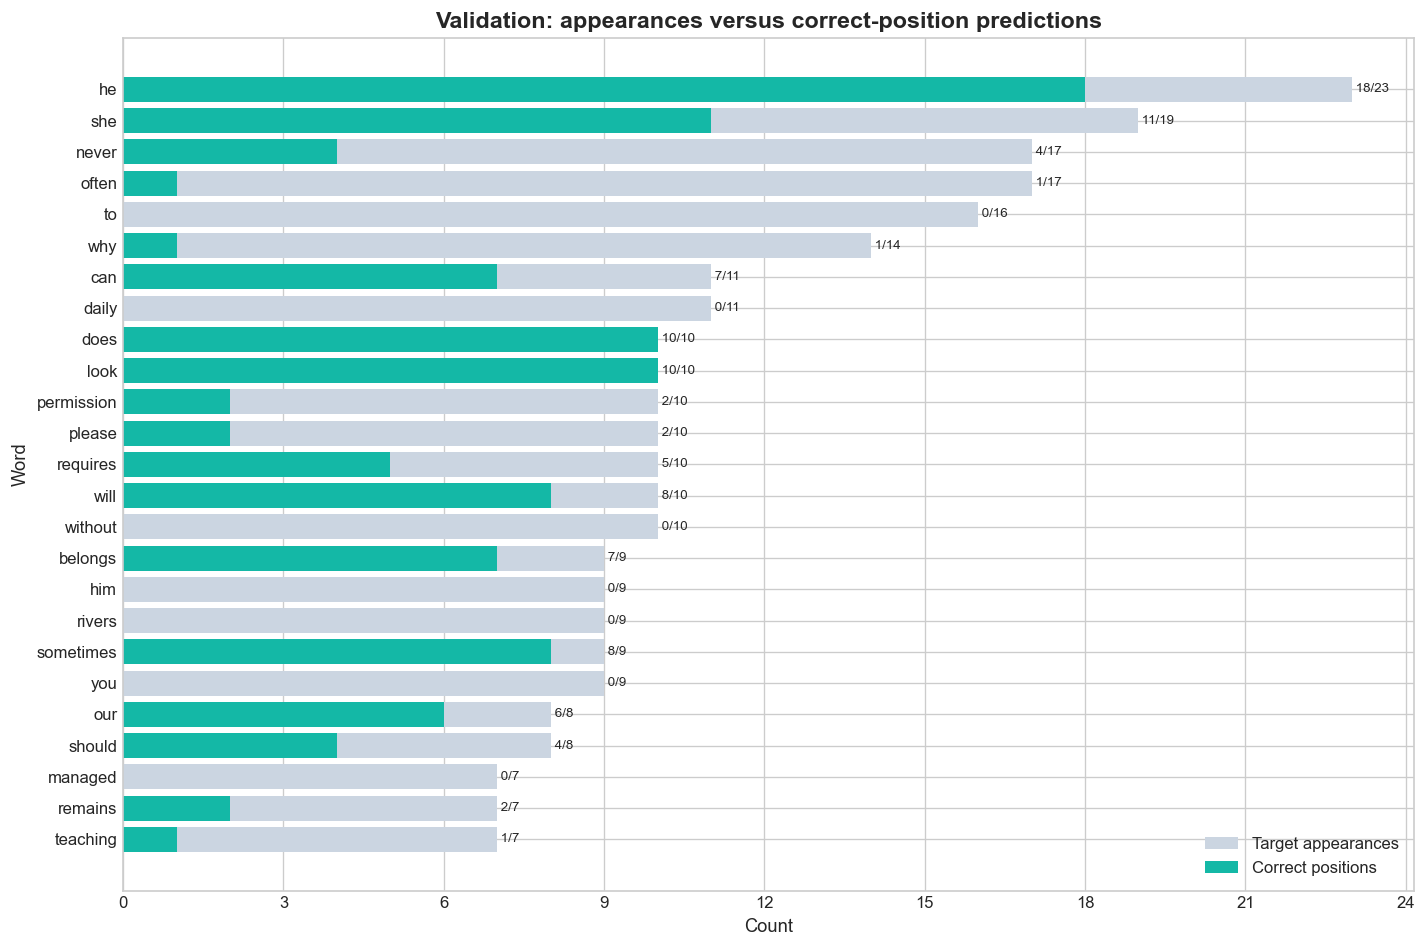

Saved: C:\Users\Shushant\Desktop\5 word transformer\experiments\new_authoritative_splits_1269\analysis\test_top_word_correct_position_counts.png


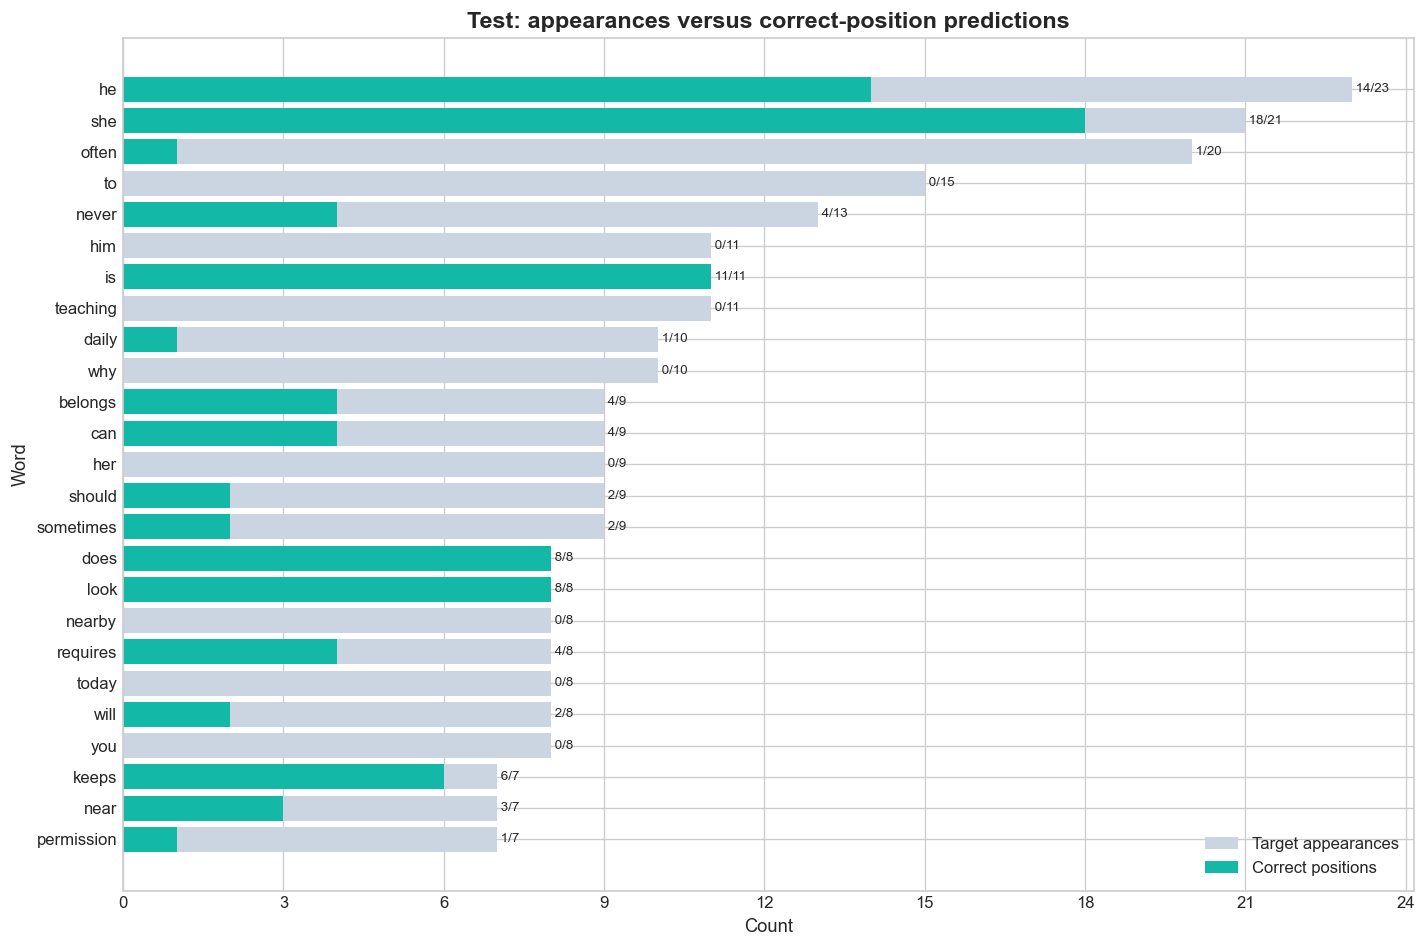

In [ ]:
for split_name in ("train", "validation", "test"):
    top_rows = position_rows_by_split[split_name][:25][::-1]
    words = [row["word"] for row in top_rows]
    appearances = [row["target_appearances"] for row in top_rows]
    correct = [row["correct_positions"] for row in top_rows]

    y = list(range(len(words)))
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(y, appearances, color="#CBD5E1", label="Target appearances")
    ax.barh(y, correct, color=COLORS["teal"], label="Correct positions")
    ax.set_yticks(y, words)
    ax.set_xlabel("Count")
    ax.set_ylabel("Word")
    ax.set_title(
        f"{split_name.title()}: appearances versus correct-position predictions",
        weight="bold",
    )
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend()
    for position, (total, right) in enumerate(zip(appearances, correct)):
        ax.text(total, position, f" {right}/{total}", va="center", fontsize=8)
    save_figure(f"{split_name}_top_word_correct_position_counts.png")

## 6. Histograms of per-word position accuracy

These histograms answer: **How many unique words fall into each correct-position accuracy range?**

Rare words can have unstable percentages. For that reason, the notebook shows both all words and words with at least three target appearances.

Saved: C:\Users\Shushant\Desktop\5 word transformer\experiments\new_authoritative_splits_1269\analysis\per_word_position_accuracy_histograms.png


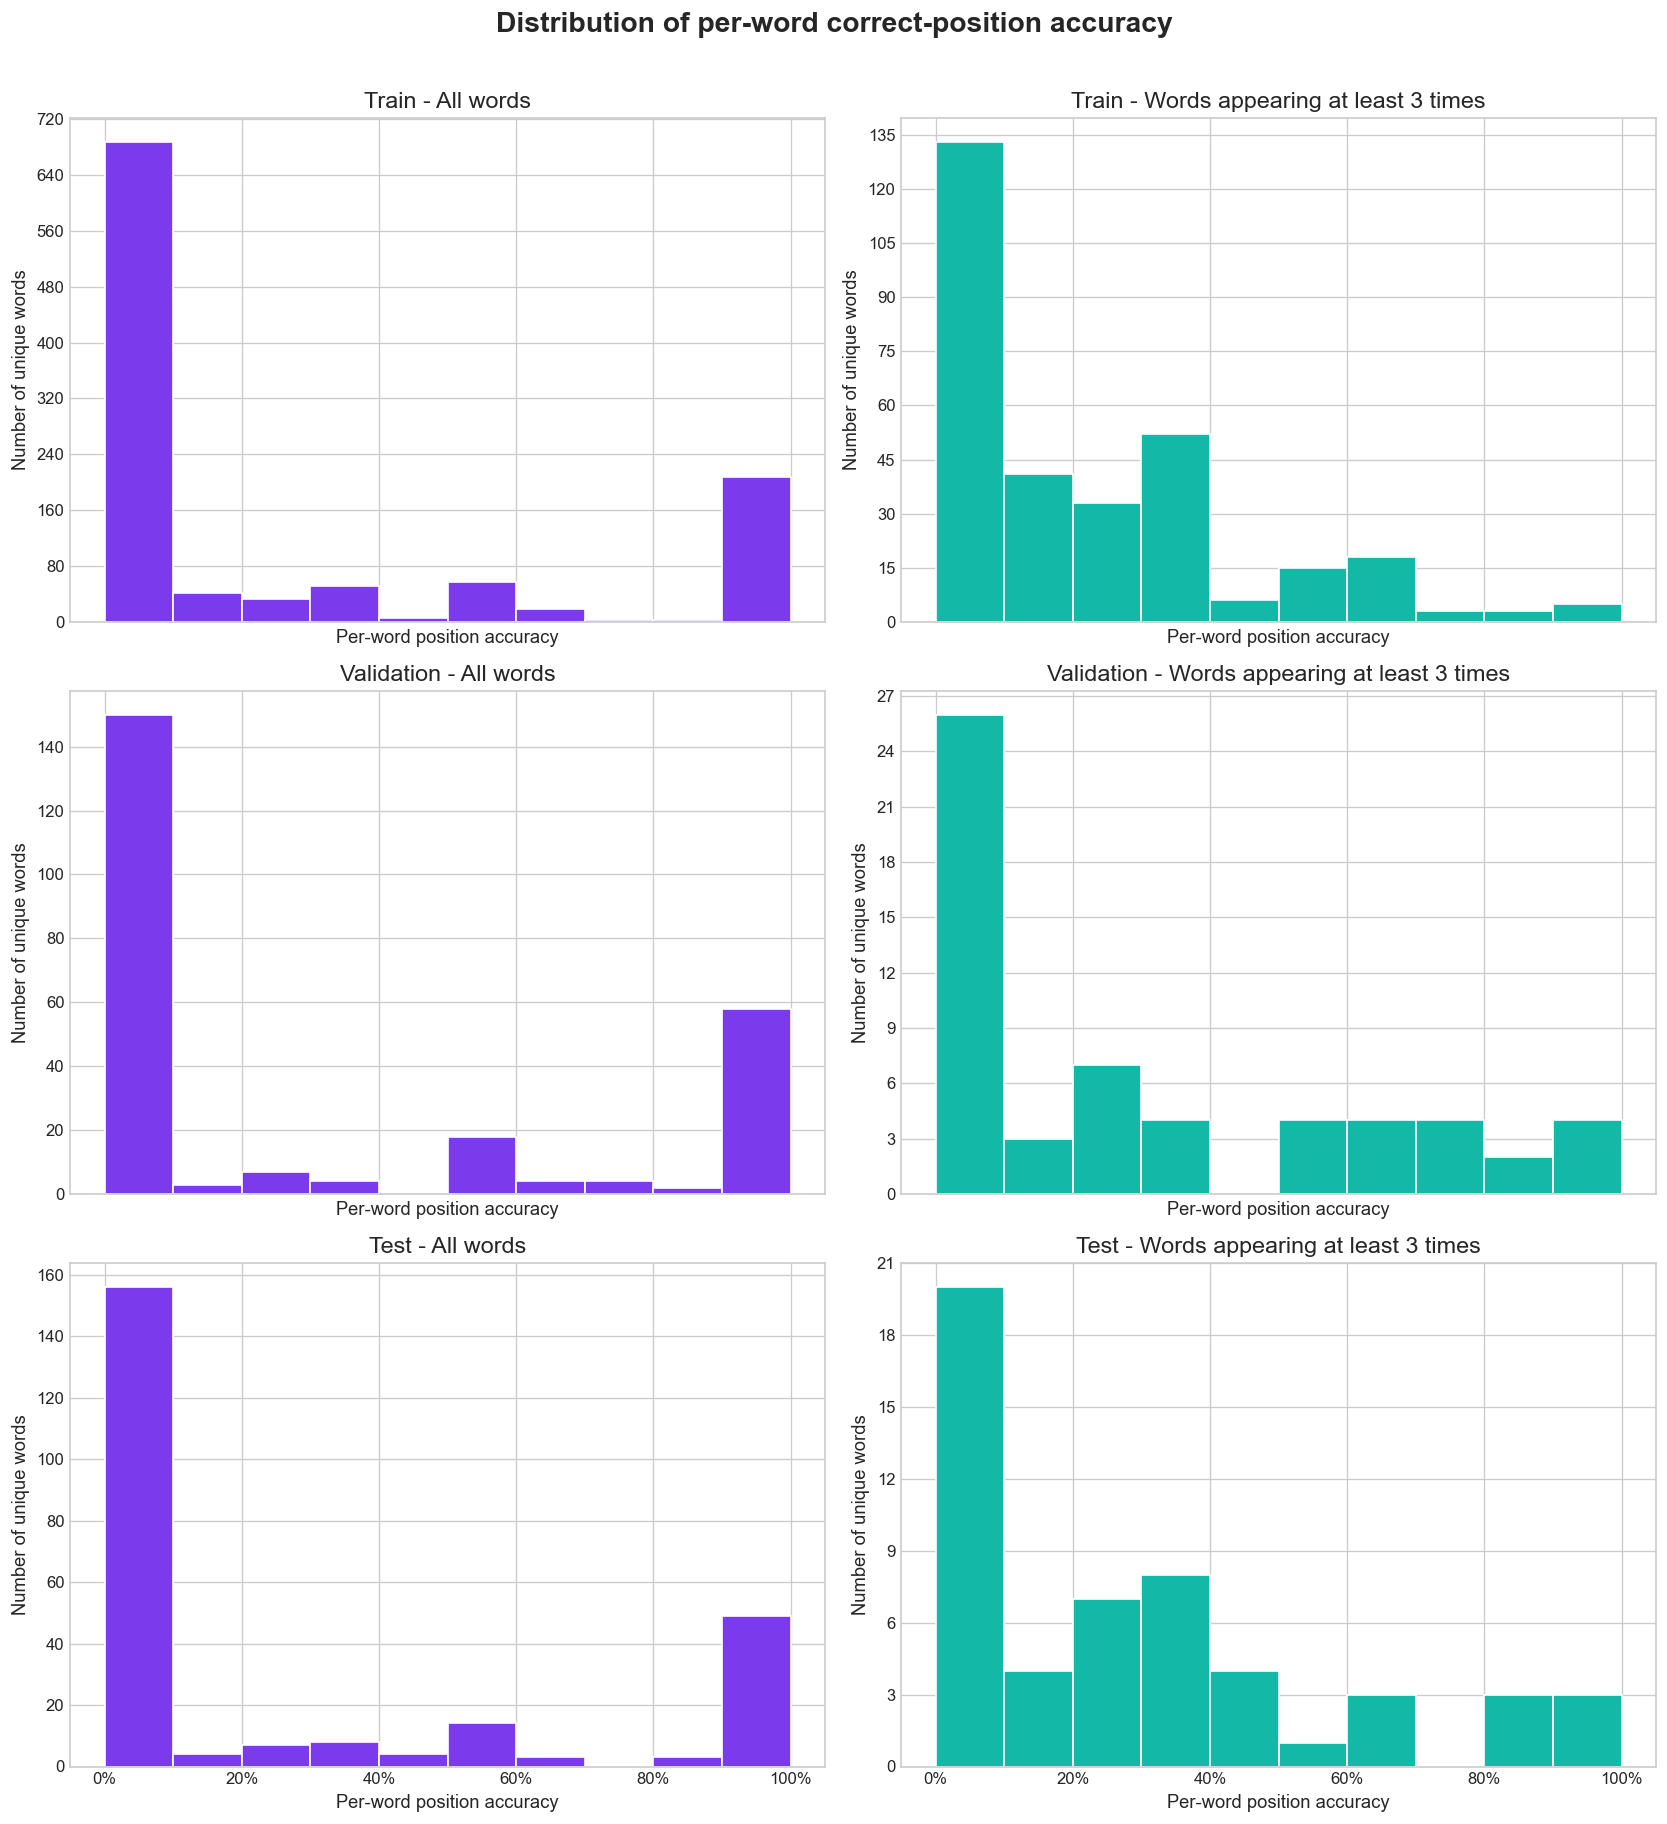

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15), sharex=True)
accuracy_bins = [value / 10 for value in range(11)]

for row_index, split_name in enumerate(("train", "validation", "test")):
    all_rows = position_rows_by_split[split_name]
    filtered_rows = [row for row in all_rows if row["target_appearances"] >= 3]

    for column_index, (rows, subtitle) in enumerate((
        (all_rows, "All words"),
        (filtered_rows, "Words appearing at least 3 times"),
    )):
        ax = axes[row_index, column_index]
        accuracies = [row["position_accuracy"] for row in rows]
        ax.hist(
            accuracies,
            bins=accuracy_bins,
            color=COLORS["violet"] if column_index == 0 else COLORS["teal"],
            edgecolor="white",
        )
        ax.set_title(f"{split_name.title()} - {subtitle}")
        ax.set_ylabel("Number of unique words")
        ax.set_xlabel("Per-word position accuracy")
        ax.xaxis.set_major_formatter(PercentFormatter(1.0))
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))

fig.suptitle("Distribution of per-word correct-position accuracy", fontsize=17, weight="bold", y=1.01)
save_figure("per_word_position_accuracy_histograms.png")

## 7. Accuracy by target position

This chart shows whether the model is better at reconstructing the first, middle, or final word of a five-word sentence.

Saved: C:\Users\Shushant\Desktop\5 word transformer\experiments\new_authoritative_splits_1269\analysis\accuracy_by_target_position.png


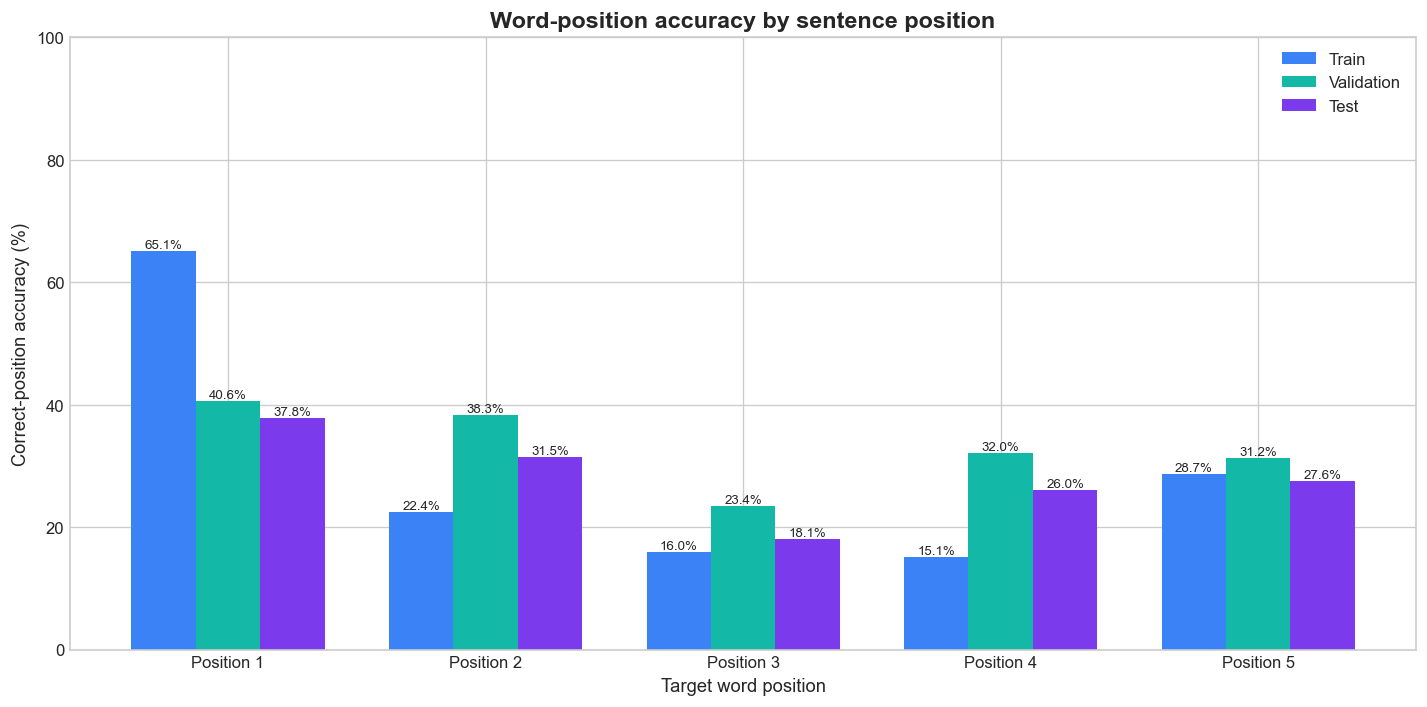

Split,Position,Appearances,Correct,Accuracy
Train,1,1014,660,65.09%
Train,2,1014,227,22.39%
Train,3,1014,162,15.98%
Train,4,1014,153,15.09%
Train,5,1014,291,28.70%
Validation,1,128,52,40.62%
Validation,2,128,49,38.28%
Validation,3,128,30,23.44%
Validation,4,128,41,32.03%
Validation,5,128,40,31.25%


In [ ]:
positions = [1, 2, 3, 4, 5]
width = 0.25
x = list(range(5))

fig, ax = plt.subplots(figsize=(12, 6))
for offset_index, split_name in enumerate(("train", "validation", "test")):
    values = [row["accuracy"] * 100 for row in per_position_by_split[split_name]]
    offsets = [value + (offset_index - 1) * width for value in x]
    bars = ax.bar(
        offsets,
        values,
        width,
        label=split_name.title(),
        color=[COLORS["blue"], COLORS["teal"], COLORS["violet"]][offset_index],
    )
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_xticks(x, [f"Position {position}" for position in positions])
ax.set_ylabel("Correct-position accuracy (%)")
ax.set_xlabel("Target word position")
ax.set_ylim(0, max(100, ax.get_ylim()[1]))
ax.set_title("Word-position accuracy by sentence position", weight="bold")
ax.legend()
save_figure("accuracy_by_target_position.png")

position_number_rows = []
for split_name in ("train", "validation", "test"):
    for row in per_position_by_split[split_name]:
        position_number_rows.append({
            "split": split_name.title(),
            "position": row["position"],
            "appearances": row["appearances"],
            "correct": row["correct"],
            "accuracy": f"{row['accuracy'] * 100:.2f}%",
        })

display_scrollable_table(
    position_number_rows,
    [
        ("split", "Split"),
        ("position", "Position"),
        ("appearances", "Appearances"),
        ("correct", "Correct"),
        ("accuracy", "Accuracy"),
    ],
    "Numbers behind the position chart",
    max_height=390,
)

## 8. Interpretation guide

- **High word frequency + high position accuracy:** the model has repeatedly seen the word and usually places it correctly.
- **High word frequency + low position accuracy:** the word is common, but the model has not learned its grammatical role reliably.
- **Low word frequency:** accuracy is uncertain because one correct or incorrect prediction can change the percentage substantially.
- **Training much higher than validation/test:** indicates memorization or overfitting.
- **Similar validation and test values:** suggests that both held-out splits have comparable difficulty.
- **100% input-word preservation:** comes from constrained decoding and does not mean the reconstructed sentence is grammatically correct.

The CSV files and PNG charts generated by this notebook are stored in:

```text
experiments/new_authoritative_splits_1269/analysis/
```